In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.linalg import svd
from scipy.fftpack import dct, idct
import cv2

In [2]:
image = cv2.imread('test.jpg', cv2.IMREAD_GRAYSCALE)
image = image.astype(float)
vector = image.flatten(order='F')
print(f"Image shape: {image.shape}")
print(f"Vector shape: {vector.shape[0]}")
print(f"First 10 elements of vector: {vector[:10]}")

Image shape: (736, 736)
Vector shape: 541696
First 10 elements of vector: [169. 169. 169. 169. 169. 169. 169. 169. 169. 169.]


In [3]:
rows, cols = image.shape
test_row, test_col = rows//2, cols//2
linear_idx = test_col * rows + test_row + 1 
print(f"\nValue at position ({test_row}, {test_col}) = {image[test_row, test_col]}")
print(f"Linear index: {linear_idx}")
print(f"Value from vector at index {linear_idx-1}: {vector[linear_idx-1]}")
reconstructed = vector.reshape(image.shape, order='F')


Value at position (368, 368) = 195.0
Linear index: 271217
Value from vector at index 271216: 195.0


In [4]:
dct_coeffs = dct(dct(image.T, norm='ortho').T, norm='ortho')
print(f"   DCT coefficients shape: {dct_coeffs.shape}")
print(f"   DCT coefficients range: [{dct_coeffs.min():.1f}, {dct_coeffs.max():.1f}]")
threshold = np.percentile(np.abs(dct_coeffs), 90)
dct_compressed = dct_coeffs.copy()
dct_compressed[np.abs(dct_compressed) < threshold] = 0
print(f"   After thresholding: {np.sum(dct_compressed != 0)} non-zero coefficients")
image_from_dct = idct(idct(dct_compressed.T, norm='ortho').T, norm='ortho')
dct_error = np.sqrt(np.mean((image - image_from_dct)**2))
print(f"   DCT reconstruction RMSE: {dct_error:.2f}")


   DCT coefficients shape: (736, 736)
   DCT coefficients range: [-4276.3, 125425.3]
   After thresholding: 54170 non-zero coefficients
   DCT reconstruction RMSE: 1.72


In [5]:
fourier_coeffs = np.fft.fft2(image)
fourier_magnitude = np.abs(fourier_coeffs)
fourier_phase = np.angle(fourier_coeffs)
print(f"   Fourier magnitude range: [{fourier_magnitude.min():.1f}, {fourier_magnitude.max():.1f}]")

image_from_fourier = np.fft.ifft2(fourier_coeffs).real
fourier_error = np.sqrt(np.mean((image - image_from_fourier)**2))
print(f"   Fourier reconstruction RMSE: {fourier_error:.2e}")

rows, cols = image.shape
crow, ccol = rows//2, cols//2
mask = np.zeros((rows, cols))
r = min(rows, cols) // 8 
y, x = np.ogrid[:rows, :cols]
mask_area = (x - ccol)**2 + (y - crow)**2 <= r*r
mask[mask_area] = 1

fourier_shifted = np.fft.fftshift(fourier_coeffs)
fourier_lowpass = fourier_shifted * mask
fourier_lowpass = np.fft.ifftshift(fourier_lowpass)
image_lowpass = np.fft.ifft2(fourier_lowpass).real
print(f"   Low-pass filtered image RMSE: {np.sqrt(np.mean((image - image_lowpass)**2)):.2f}")

   Fourier magnitude range: [0.7, 92312990.0]
   Fourier reconstruction RMSE: 4.18e-14
   Low-pass filtered image RMSE: 3.35


In [6]:
U, s, Vt = svd(image, full_matrices=False)
print(f"Number of singular values: {len(s)}")
print(f"Top 10 singular values: {s[:10]}")
total_energy = np.sum(s**2)
cumulative_energy = np.cumsum(s**2) / total_energy * 100
ranks = [5, 10, 20, 50, 100]

svd_results = {}
for r in ranks:
    if r > len(s):
        continue
    U_r = U[:, :r]
    s_r = s[:r]
    Vt_r = Vt[:r, :]
    
    approx = U_r @ np.diag(s_r) @ Vt_r
    approx = np.clip(approx, 0, 255)
    svd_results[f'rank_{r}'] = approx
    energy = cumulative_energy[r-1]
    error = np.linalg.norm(image - approx, 'fro') / np.linalg.norm(image, 'fro')
    m, n = image.shape
    original_size = m * n
    compressed_size = m * r + r + r * n
    ratio = original_size / compressed_size


Number of singular values: 736
Top 10 singular values: [125944.73014711  10533.1578986    6207.29063246   4801.55641093
   3811.85479633   2538.45723066   2441.87225143   2138.69712292
   1997.92454583   1727.75989014]


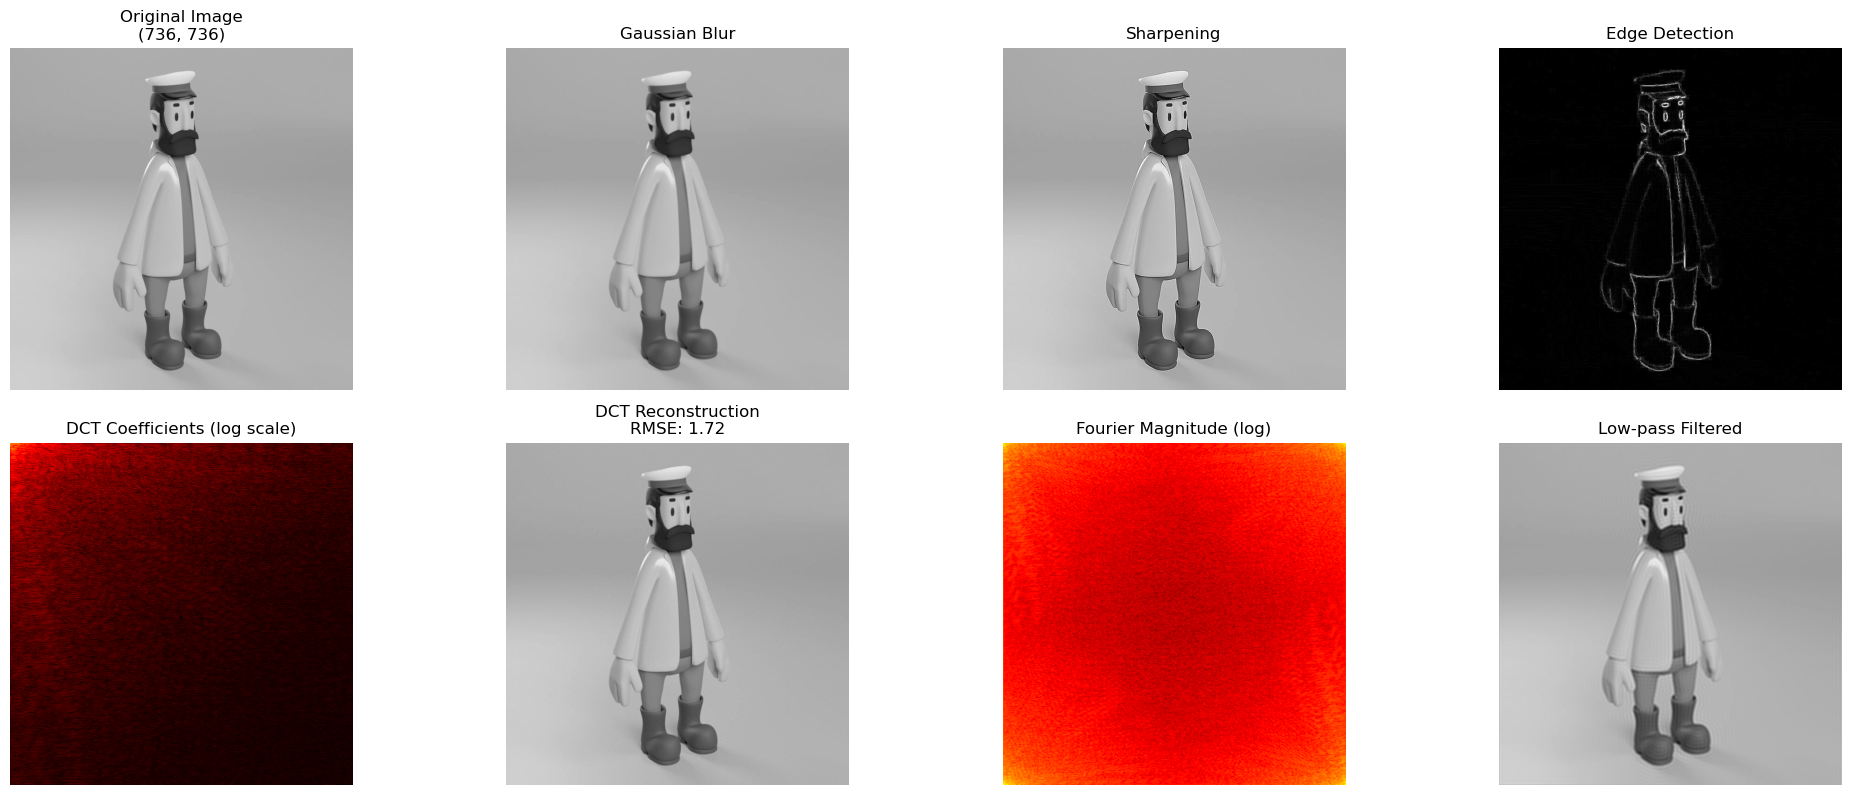

In [7]:
# Define convolution results before plotting
from scipy import signal

# Create convolution kernels
gaussian_kernel = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
edge_kernel = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])

# Apply convolutions
conv_results = {
    'Gaussian Blur': signal.convolve2d(image, gaussian_kernel, mode='same', boundary='symm'),
    'Sharpen': signal.convolve2d(image, sharpen_kernel, mode='same', boundary='symm'),
    'Edge Detection': np.abs(signal.convolve2d(image, edge_kernel, mode='same', boundary='symm'))
}

# Ensure values are in valid range
conv_results['Gaussian Blur'] = np.clip(conv_results['Gaussian Blur'], 0, 255)
conv_results['Sharpen'] = np.clip(conv_results['Sharpen'], 0, 255)
conv_results['Edge Detection'] = np.clip(conv_results['Edge Detection'], 0, 255)

# Now proceed with your plotting code
fig = plt.figure(figsize=(20, 12))

plt.subplot(3, 4, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title(f'Original Image\n{image.shape}')
plt.axis('off')

plt.subplot(3, 4, 2)
plt.imshow(conv_results['Gaussian Blur'], cmap='gray', vmin=0, vmax=255)
plt.title('Gaussian Blur')
plt.axis('off')

plt.subplot(3, 4, 3)
plt.imshow(conv_results['Sharpen'], cmap='gray', vmin=0, vmax=255)
plt.title('Sharpening')
plt.axis('off')

plt.subplot(3, 4, 4)
plt.imshow(conv_results['Edge Detection'], cmap='gray', vmin=0, vmax=255)
plt.title('Edge Detection')
plt.axis('off')

plt.subplot(3, 4, 5)
plt.imshow(np.log(np.abs(dct_coeffs) + 1), cmap='hot')
plt.title('DCT Coefficients (log scale)')
plt.axis('off')

plt.subplot(3, 4, 6)
plt.imshow(image_from_dct, cmap='gray', vmin=0, vmax=255)
plt.title(f'DCT Reconstruction\nRMSE: {dct_error:.2f}')
plt.axis('off')

plt.subplot(3, 4, 7)
plt.imshow(np.log(fourier_magnitude + 1), cmap='hot')
plt.title('Fourier Magnitude (log)')
plt.axis('off')

plt.subplot(3, 4, 8)
plt.imshow(image_lowpass, cmap='gray', vmin=0, vmax=255)
plt.title('Low-pass Filtered')
plt.axis('off')

plt.tight_layout()
plt.show()

Number of singular values: 736
Top 5 singular values: [125944.73014711  10533.1578986    6207.29063246   4801.55641093
   3811.85479633]


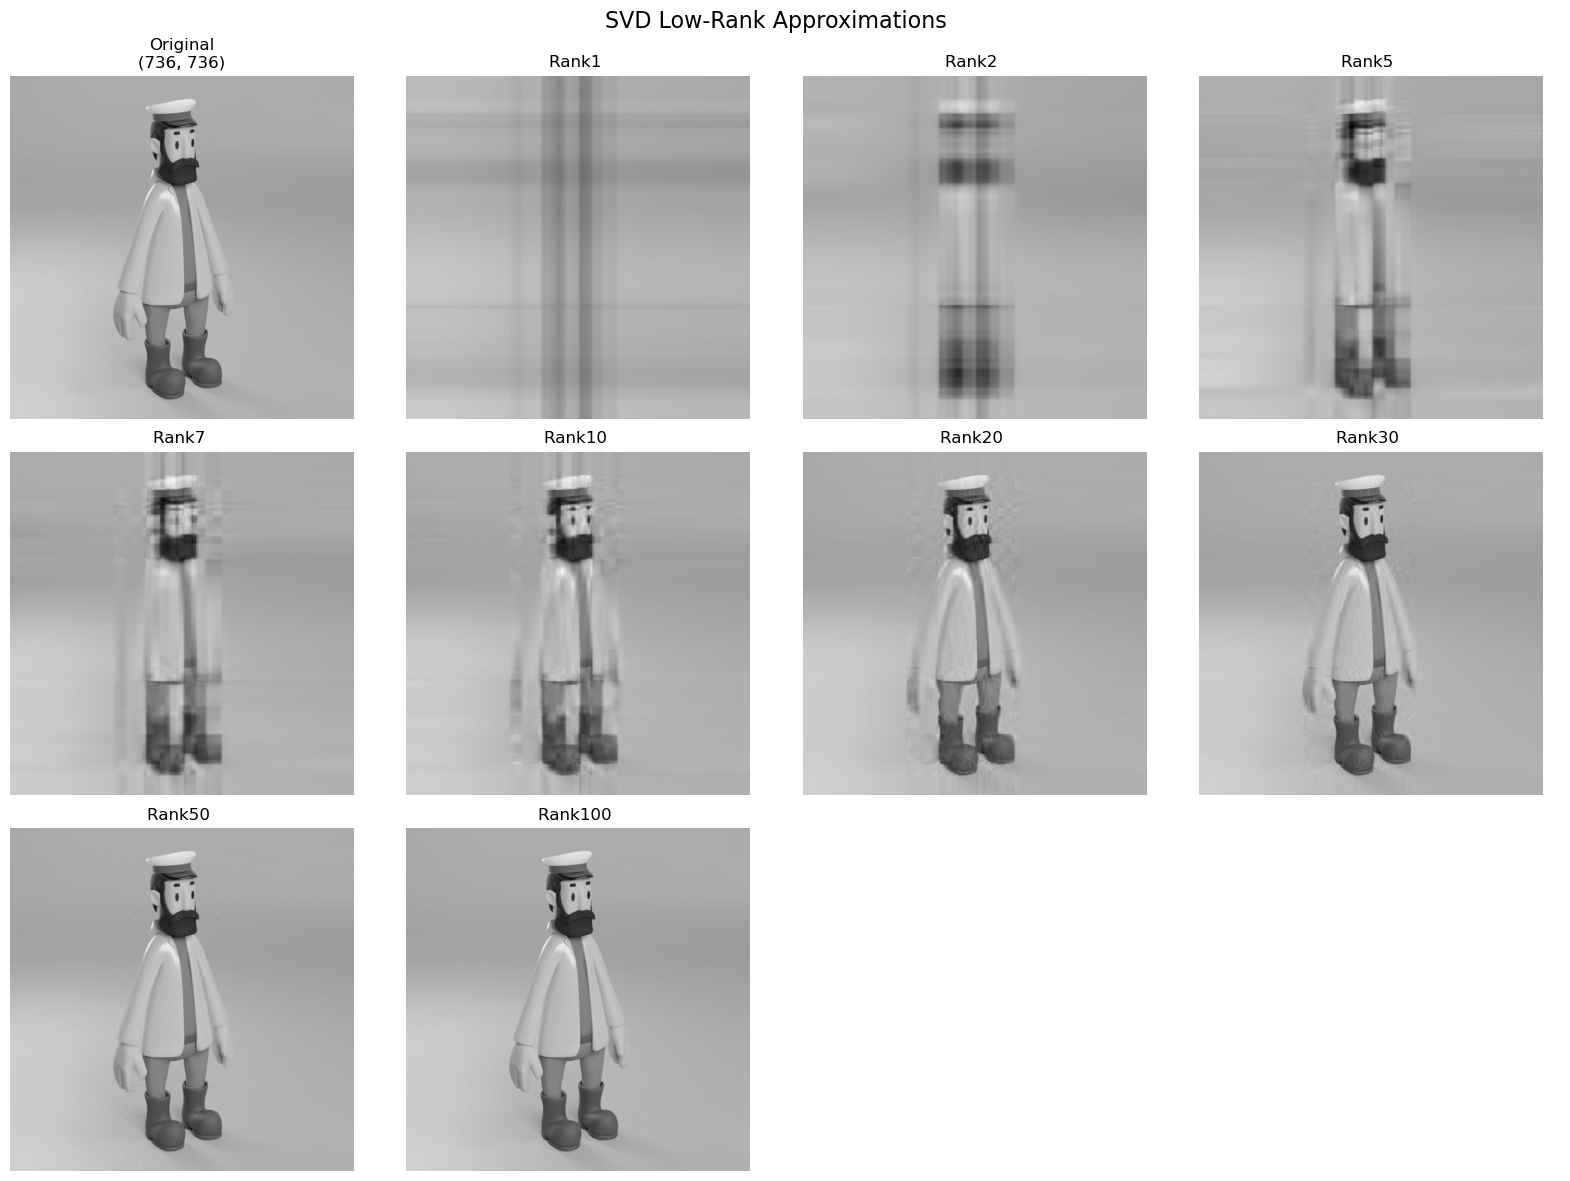

In [8]:
U, s, Vt = svd(image, full_matrices=False)
print(f"Number of singular values: {len(s)}")
print(f"Top 5 singular values: {s[:5]}")
total_energy = np.sum(s**2)
cumulative_energy = np.cumsum(s**2) / total_energy * 100
ranks = [1, 2, 5, 7, 10, 20,30 ,  50, 100]

svd_results = {}
for r in ranks:
    if r > len(s):
        continue
    U_r = U[:, :r]
    s_r = s[:r]
    Vt_r = Vt[:r, :]
    approx = U_r @ np.diag(s_r) @ Vt_r
    approx = np.clip(approx, 0, 255)
    svd_results[f'rank_{r}'] = approx
    energy = cumulative_energy[r-1]
    error = np.linalg.norm(image - approx, 'fro') / np.linalg.norm(image, 'fro')
    m, n = image.shape
    original_size = m * n
    compressed_size = m * r + r + r * n
    ratio = original_size / compressed_size


valid_ranks = [r for r in ranks if r <= len(s)]
n_ranks = len(valid_ranks)
total_images = n_ranks + 1 
n_cols = 4
n_rows = (total_images + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
fig.suptitle('SVD Low-Rank Approximations', fontsize=16)
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Original\n{image.shape}')
axes[0].axis('off')
for i, r in enumerate(valid_ranks):
    plot_idx = i + 1 
    
    if plot_idx < len(axes): 
        key = f'rank_{r}'
        error = np.linalg.norm(image - svd_results[key], 'fro') / np.linalg.norm(image, 'fro')
        energy = cumulative_energy[r-1]
        axes[plot_idx].imshow(svd_results[key], cmap='gray', vmin=0, vmax=255)
        axes[plot_idx].set_title(f'Rank{r} ')
        axes[plot_idx].axis('off')

for idx in range(total_images, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

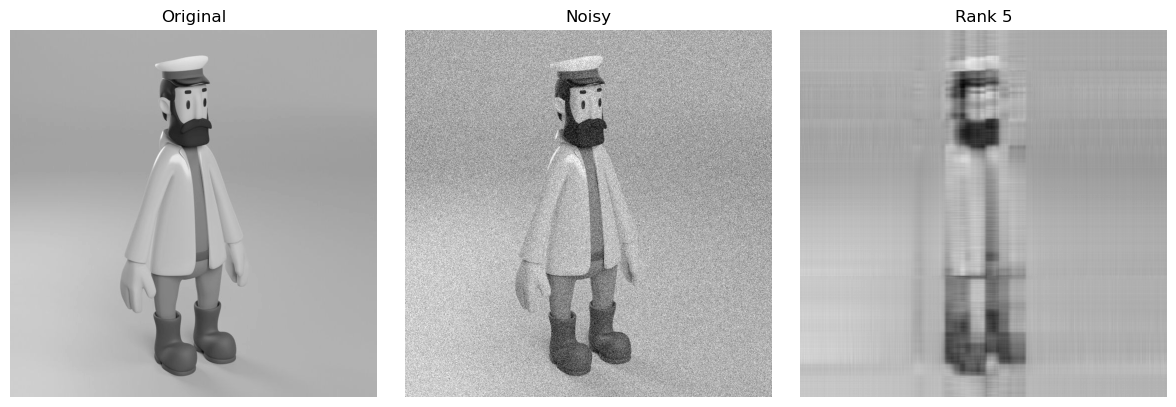

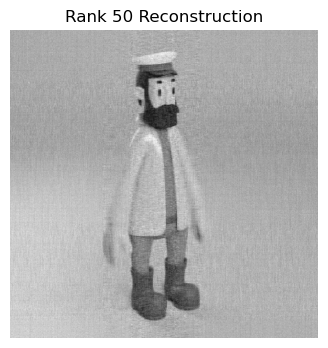

In [ ]:
np.random.seed(42)
noisy = image + np.random.normal(0, 25, image.shape)
noisy = np.clip(noisy, 0, 255)
U, s, Vt = svd(noisy, full_matrices=False)

ranks = [5, 50]
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy, cmap='gray', vmin=0, vmax=255)
plt.title('Noisy')
plt.axis('off')
r = ranks[0]
reconstructed1 = U[:, :r] @ np.diag(s[:r]) @ Vt[:r, :]
reconstructed1 = np.clip(reconstructed1, 0, 255)


plt.subplot(1, 3, 3)
plt.imshow(reconstructed1, cmap='gray', vmin=0, vmax=255)
plt.title(f'Rank {r}')
plt.axis('off')

plt.tight_layout()
plt.show()
plt.figure(figsize=(6, 4))
r = ranks[1]
reconstructed2 = U[:, :r] @ np.diag(s[:r]) @ Vt[:r, :]
reconstructed2 = np.clip(reconstructed2, 0, 255)
plt.imshow(reconstructed2, cmap='gray', vmin=0, vmax=255)
plt.title(f'Rank {r} Reconstruction')
plt.axis('off')
plt.show()